In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
from pylab import *

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

A new version is available: IDL 9.0
https://www.nv5geospatialsoftware.com/Product-Downloads/
 
Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [2]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [3]:
def get_obs_data(box, vege_mask_flag, start_year):
         
    
    #d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_HPB_ensMean.nc')
    d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')

    #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
    da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    if box != 'full':
        da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        da = da.where(vege_mask>0)
        
    da = da.sel(time=slice(start_year,"2021"))
    da = da.where(~d4pdf.isnull())
    
    da = da.stack(pixel=("latitude", "longitude"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    del da
    
    return(array)


In [4]:
def get_mean_and_noise(scen, box, vege_mask_flag, start_year):
    
    # 95th percentile
    #era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
    # 6-month fire season
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    
    # 95th percentile
    #ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_'+scen+'_ensMean.nc')
    # 6-month fire season
    ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice(start_year,"2021"))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        #mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_'+scen+'_m'+number+'.nc')
        mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        if vege_mask_flag:
            mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice(start_year,"2021"))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
        del mem_da
        del diff_array

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()

    del ens_mean
    
    return((ens_mean_array, np.array(noise)))


In [5]:
def plot_result(scan_beta_est):

    fig,axs = plt.subplots(figsize=(12,10))

    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        axs.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
        axs.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

        axs.vlines(j+3,low_2,up_2,colors=['blue'])
        axs.vlines(j+3,low_1,up_1,colors=['red'])

        axs.axhline(0,-0.5,1.5)
        axs.axhline(1,-0.5,1.5)

    axs.legend()
    axs.set_ylim(-1,4)

    plt.title('BC ERA5/d4pdf fire season FWI (1979-2021)')
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    plt.show()
    #plt.close(fig)
    

In [6]:
'''
Create vegetation land mask
'''

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]

d4pdf_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')

vege_ds = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
vege_ds = vege_ds.interp(longitude=d4pdf_da.longitude, latitude=d4pdf_da.latitude, method="linear")

full_lai = vege_ds.lai_hv + vege_ds.lai_lv
full_lai_max = full_lai.max('time')

vege_mask = full_lai_max.where(full_lai_max>3.5)


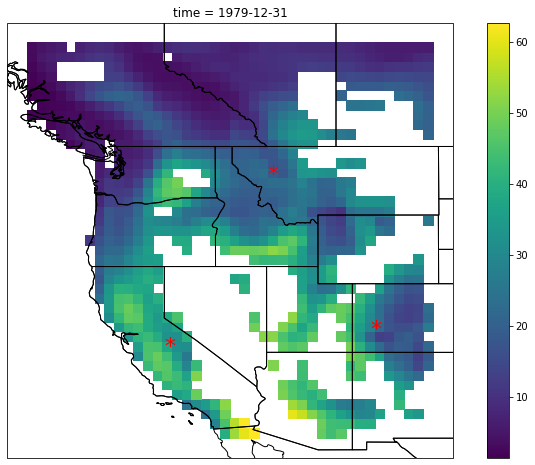

In [7]:
box = [(32,55),(232,256)]

da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
da = da.where(vege_mask>0)
da = da.sel(time=slice("1979","2021"))

fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)

western_Montana = [47,246]
Colorado = [38,252]
central_California = [37,240]

axs.text(western_Montana[1],western_Montana[0],'*',c='red',size=22,transform=ccrs.PlateCarree())#, transform=axs.transAxes)
axs.text(Colorado[1],Colorado[0],'*',c='red',size=22,transform=ccrs.PlateCarree())#, transform=axs.transAxes)
axs.text(central_California[1],central_California[0],'*',c='red',size=22,transform=ccrs.PlateCarree())#, transform=axs.transAxes)

plt.show()
plt.close(fig)

In [28]:
'''
create dataset with d4pdf All, Nat, Ant signals and Nat and Ant fingerprints from finger_trans
'''

def plot_fingerprint(Ant_da,finger_trans,start_year):

    da = Ant_da.sel(time=slice(start_year,"2021"))
    
    pixel = da.stack(pixel=("latitude", "longitude"))
    no_nan = pixel.dropna("pixel", how="all")
    shape = no_nan.Ant.data.shape

    # add fingerprints
    all_finger_trans = np.array([val[0] for val in finger_trans])
    nat_finger_trans = -1*np.array([val[1] for val in finger_trans])
    ant_finger_trans = all_finger_trans - nat_finger_trans

    nat_finger_from_trans = (1/(nat_finger_trans+1)-1)
    ant_finger_from_trans = (1/(ant_finger_trans+1)-1)

    add_fingers = no_nan.assign(nat_finger_from_trans=(['time','lev','pixel'],nat_finger_from_trans.reshape(shape)),
                                ant_finger_from_trans=(['time','lev','pixel'],ant_finger_from_trans.reshape(shape)),
                                )

    unstack = add_fingers.unstack("pixel")
    
    fig,axs = plt.subplots(figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))
    cmap = cm.get_cmap('RdBu_r', 15)
    
    xr.apply_ufunc(get_linregress_slope, unstack['ant_finger_from_trans'], input_core_dims=[["time"]], vectorize = True).plot(ax=axs,transform=ccrs.PlateCarree(),vmin=-.4e-6,vmax=0.4e-6,cmap=cmap)

    axs.coastlines()  # cartopy function
    axs.add_feature(cf.BORDERS)
    axs.add_feature(cf.STATES)
    
    axs.text(0.08,0.08,start_year,transform=axs.transAxes,fontsize=22)
        
    plt.savefig('/home/queenle/fire_attribution/figures/plots/fingerprints/d4pdf/d4PDF_'+start_year+'.png')
    plt.close()
    

In [30]:
'''
OF at one truncation for FINGER_TRUNC output
'''

box = [(32,55),(232,256)]#,'full',[(32,55),(232,250)],[(32,55),(235,245)]]

vege_mask_flag = True

era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')

Ant_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc')
Ant_da = Ant_da.rename({'FWI':'Ant'})

Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Ant_da = Ant_da.where(vege_mask>0)
Ant_da = Ant_da.where(~era5_da.isnull())

for year in range(1951,2000):

    start_year = str(year)
    
    #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
    da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    if box != 'full':
        da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    if vege_mask_flag:
        da = da.where(vege_mask>0)
    da = da.sel(time=slice(start_year,"2021"))

    IDL.retall

    #print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise('HPB', box, vege_mask_flag, start_year)
    #print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise('HPB_NAT', box, vege_mask_flag, start_year)

    #print('getting obs')
    data_obs = get_obs_data(box, vege_mask_flag, start_year)
    #print('got obs')
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
    data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

    #print('got arrays')

    trunc = 60

    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.finger_trans = 1
    IDL.z_best = 1

    #print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, finger_trans=finger_trans, z_best=z_best")

    finger_trans = IDL.finger_trans
    z_best = IDL.z_best

    beta_est = IDL.BETA_EST

    best_ant,low_ant,up_ant = beta_est[0][0],beta_est[1][0],beta_est[2][0]
    best_nat,low_nat,up_nat = beta_est[0][1],beta_est[1][1],beta_est[2][1]

    plot_fingerprint(Ant_da, finger_trans,start_year)
    
    print(start_year)


In [18]:
'''
create dataset with d4pdf All, Nat, Ant signals and Nat and Ant fingerprints from finger_trans
'''

era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
box = [(32,55),(232,256)]

All_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
All_da = All_da.rename({'FWI':'All'})
Nat_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')
Nat_da = Nat_da.rename({'FWI':'Nat'})

d4pdf_ds = xr.merge([All_da,Nat_da])
d4pdf_ds = d4pdf_ds.assign(Ant=d4pdf_ds.All - d4pdf_ds.Nat)

d4pdf_ds = d4pdf_ds.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
d4pdf_ds = d4pdf_ds.where(vege_mask>0)
d4pdf_ds = d4pdf_ds.sel(time=slice("1979","2021"))
d4pdf_ds = d4pdf_ds.where(~era5_da.isnull())

d4pdf_pixel = d4pdf_ds.stack(pixel=("latitude", "longitude"))
d4pdf_no_nan = d4pdf_pixel.dropna("pixel", how="all")
shape = d4pdf_no_nan.Ant.data.shape

# add fingerprints
all_finger_trans = np.array([val[0] for val in finger_trans])
nat_finger_trans = -1*np.array([val[1] for val in finger_trans])
ant_finger_trans = all_finger_trans - nat_finger_trans

nat_finger_from_trans = (1/(nat_finger_trans+1)-1)
ant_finger_from_trans = (1/(ant_finger_trans+1)-1)

est_obs_from_trans = best_ant * ant_finger_from_trans + best_nat * nat_finger_from_trans

z_best_all_finger = np.array(z_best[0])
z_best_nat_finger = np.array(z_best[1])
z_best_ant_finger = z_best_all_finger - z_best_nat_finger

z_best_obs = np.array(z_best[2])
my_z_best_obs = best_ant*z_best_ant_finger + best_nat*z_best_nat_finger

d4pdf_add_fingers = d4pdf_no_nan.assign(all_finger_trans=(['time','lev','pixel'],all_finger_trans.reshape(shape)),
                                        nat_finger_trans=(['time','lev','pixel'],nat_finger_trans.reshape(shape)),
                                        ant_finger_trans=(['time','lev','pixel'],ant_finger_trans.reshape(shape)),
                                        nat_finger_from_trans=(['time','lev','pixel'],nat_finger_from_trans.reshape(shape)),
                                        ant_finger_from_trans=(['time','lev','pixel'],ant_finger_from_trans.reshape(shape)),
                                        est_obs_from_trans=(['time','lev','pixel'],est_obs_from_trans.reshape(shape)),
                                        nat_finger_from_zbest=(['time','lev','pixel'],z_best_nat_finger.reshape(shape)),
                                        ant_finger_from_zbest=(['time','lev','pixel'],z_best_ant_finger.reshape(shape)),
                                        all_finger_from_zbest=(['time','lev','pixel'],z_best_all_finger.reshape(shape)),
                                        est_obs_from_zbest=(['time','lev','pixel'],z_best_obs.reshape(shape)),
                                        my_est_obs_from_zbest=(['time','lev','pixel'],my_z_best_obs.reshape(shape)))

d4pdf_unstack = d4pdf_add_fingers.unstack("pixel")


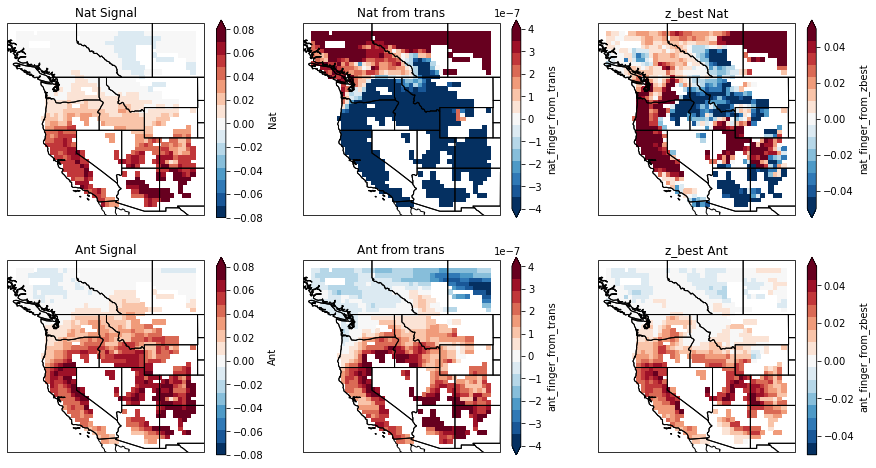

In [19]:
'''
plot Nat + Ant signals versus fingerprints
'''

fig,axs = plt.subplots(2,3,figsize=(15,8),sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

titles = ['Nat Signal','Nat from trans','z_best Nat','Ant Signal','Ant from trans','z_best Ant']
for i,var in enumerate(['Nat','nat_finger_from_trans','nat_finger_from_zbest','Ant','ant_finger_from_trans','ant_finger_from_zbest']):
    
    if i in [0,3]:
        rnge = [-0.08,0.08] 
    elif i in [1,4]:
        rnge = [-.4e-6,.4e-6]
    elif i in [2,5]:
        rnge = [-0.05,0.05] 
    
    cmap = cm.get_cmap('RdBu_r', 15)
    
    xr.apply_ufunc(get_linregress_slope, d4pdf_unstack[var], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)

    axs[i].coastlines()  # cartopy function
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_title(titles[i])


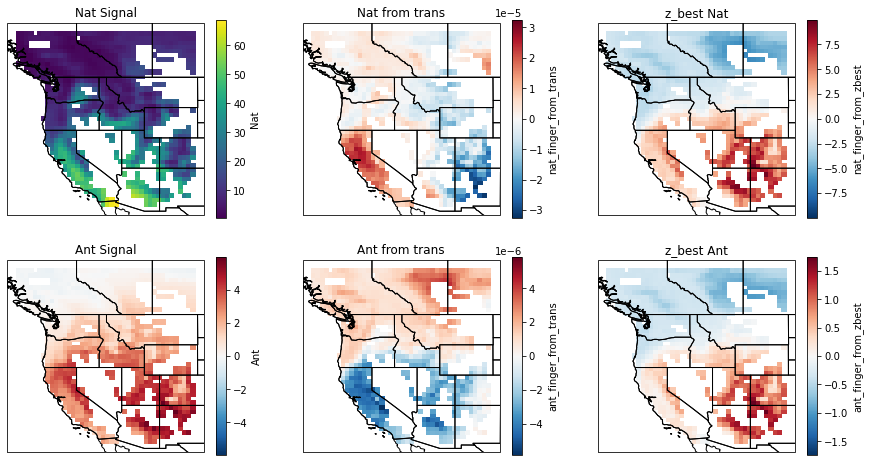

In [20]:
'''
plot Nat + Ant signals versus fingerprints
'''

fig,axs = plt.subplots(2,3,figsize=(15,8),sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

titles = ['Nat Signal','Nat from trans','z_best Nat','Ant Signal','Ant from trans','z_best Ant']
for i,var in enumerate(['Nat','nat_finger_from_trans','nat_finger_from_zbest','Ant','ant_finger_from_trans','ant_finger_from_zbest']):
    
    if i in [0,3]:
        rnge = [-0.08,0.08] 
    elif i in [1,4]:
        rnge = [-.4e-6,.4e-6]
    elif i in [2,5]:
        rnge = [-0.05,0.05] 
    
    cmap = cm.get_cmap('RdBu_r', 15)
    
    d4pdf_unstack[var].mean('time').plot(ax=axs[i],transform=ccrs.PlateCarree())
    #xr.apply_ufunc(get_linregress_slope, d4pdf_unstack[var], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)

    axs[i].coastlines()  # cartopy function
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_title(titles[i])


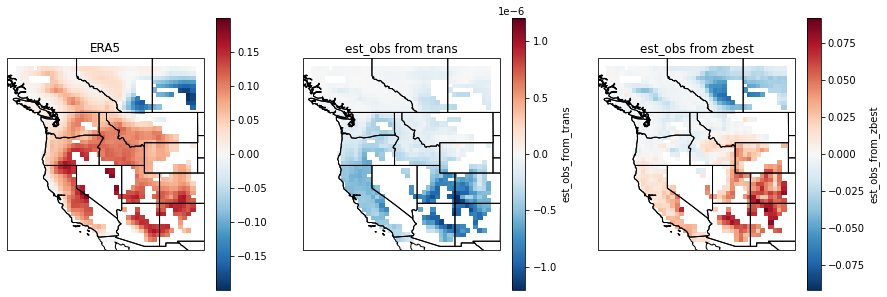

In [63]:
'''
plot Nat + Ant signals versus fingerprints
'''

box = [(32,55),(232,256)]
da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
da = da.where(vege_mask>0)
era5_da = da.sel(time=slice("1959","2014"))

fig,axs = plt.subplots(1,3,figsize=(15,5),sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

das = [era5_da,d4pdf_unstack['est_obs_from_trans'],d4pdf_unstack['est_obs_from_zbest']]
titles = ['ERA5','est_obs from trans','est_obs from zbest']
for i,da in enumerate(das):
    
    cmap = cm.get_cmap('RdBu_r', 15)
    
    xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i])#,transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)

    axs[i].coastlines()  # cartopy function
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_title(titles[i])


In [33]:
all_finger_trans = np.array([val[0] for val in finger_trans])
nat_finger_trans = -1*np.array([val[1] for val in finger_trans])
ant_finger_trans = all_finger_trans - nat_finger_trans

nat_finger = (1/(nat_finger_trans+1)-1)
ant_finger = (1/(ant_finger_trans+1)-1)

print(nat_finger)
print('')
print(ant_finger)
print('')
print(best_ant * ant_finger + best_nat * nat_finger)


[ 6.76314112e-06  5.93273521e-06  9.50215140e-06 ... -1.26380050e-05
 -1.25185915e-05 -1.19687769e-05]

[-5.26819976e-07  9.58629814e-07  1.28409834e-06 ...  1.82648494e-06
  1.74768256e-06  2.04102890e-06]

[ 4.04572827e-06  5.69006935e-06  8.73479397e-06 ... -6.29113578e-06
 -6.32443968e-06 -5.48892422e-06]


In [51]:
z_best_all_finger = np.array(z_best[0])
z_best_nat_finger = np.array(z_best[1])
z_best_ant_finger = z_best_all_finger - z_best_nat_finger

z_best_obs = np.array(z_best[2])


print(z_best_all_finger)
print('')
print(z_best_nat_finger)
print('\n\n\n')
print(z_best_ant_finger)
print('\n\n')
print(z_best_obs)
print('')

print(best_ant*z_best_ant_finger+best_nat*z_best_nat_finger)
print('')


[ 0.58250031 -1.56990018 -2.99339593 ... -0.93055658 -0.87662029
 -1.50303221]

[ 0.6731197  -1.24223707 -2.48641542 ... -1.00950243 -0.97363998
 -1.53011733]




[-0.09061939 -0.32766311 -0.50698051 ...  0.07894585  0.09701969
  0.02708513]



[ 0.34511528 -1.38272238 -2.54327697 ... -0.6034199  -0.55051977
 -1.05412154]

[ 0.34511529 -1.38272242 -2.54327706 ... -0.60341992 -0.55051978
 -1.05412157]



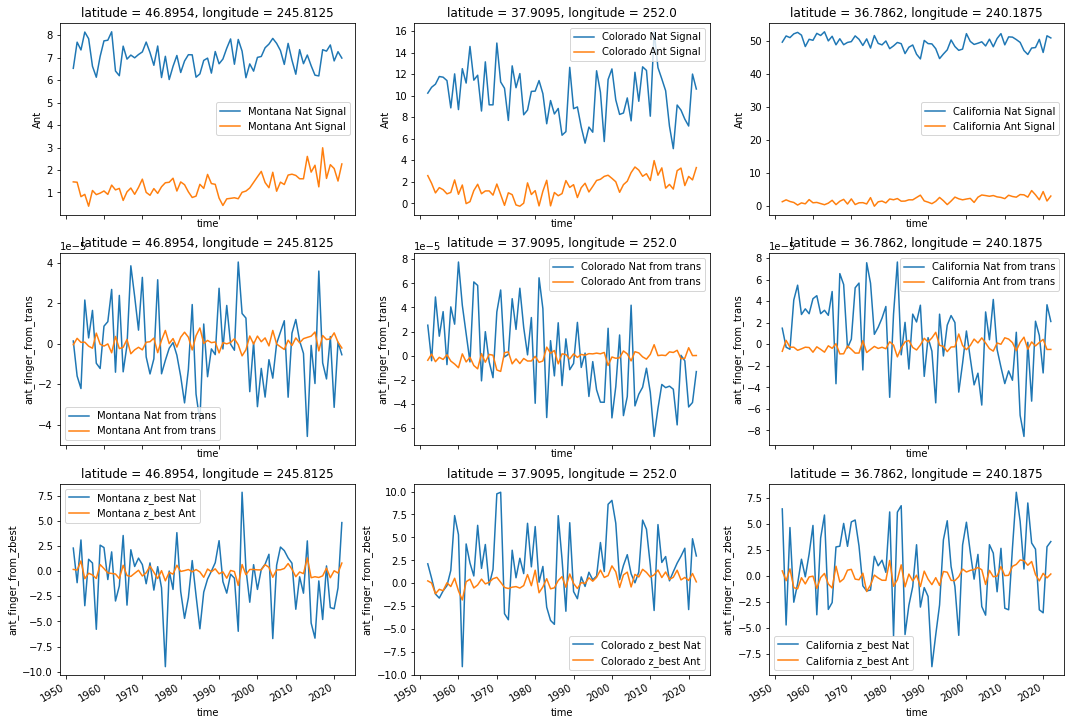

In [64]:
western_Montana = [47,246]
Colorado = [38,252]
central_California = [37,240]

titles = ['Nat Signal','Nat from trans','z_best Nat','Ant Signal','Ant from trans','z_best Ant']


fig,axs = plt.subplots(3,3,figsize=(18,12),sharex=True)
titles = ['Nat Signal','Ant Signal','Nat from trans','Ant from trans','z_best Nat','z_best Ant']
labels = ['Montana','Colorado','California']
for i,var in enumerate(['Nat','Ant','nat_finger_from_trans','ant_finger_from_trans','nat_finger_from_zbest','ant_finger_from_zbest']):
    
    da = d4pdf_unstack[var]
    
    montana_cell = da.sel(latitude=western_Montana[0],longitude=western_Montana[1],method='nearest')
    colorado_cell = da.sel(latitude=Colorado[0],longitude=Colorado[1],method='nearest')
    california_cell = da.sel(latitude=central_California[0],longitude=central_California[1],method='nearest')

    for j,cell in enumerate([montana_cell,colorado_cell,california_cell]):
        if i < 2:
            row = 0 
        elif i < 4:
            row = 1
        else:
            row = 2
            
        cell.plot(ax=axs[row][j],label=labels[j] + ' ' + titles[i])
        axs[row][j].legend()


In [13]:
finger_trans = IDL.FINGER_TRANS
beta_est = IDL.BETA_EST
data_obs = IDL.DATA_OBS

finger_ant = np.array([val[0] for val in finger_trans])
finger_nat = (-1)*np.array([val[1] for val in finger_trans])

best_ant,low_ant,up_ant = beta_est[0][0],beta_est[1][0],beta_est[2][0]
best_nat,low_nat,up_nat = beta_est[0][1],beta_est[1][1],beta_est[2][1]

print('BETA_EST[0] = FINGER_TRANS[*,0] * DATA_OBS')
print(str(best_ant) + ' = ' + str(np.dot(finger_ant,data_obs)))

print('\n\n')

print('BETA_EST[1] = FINGER_TRANS[*,1] * DATA_OBS')
print(str(best_nat) + ' = ' + str(np.dot(finger_nat,data_obs)))


BETA_EST[0] = FINGER_TRANS[*,0] * DATA_OBS
1.5069997 = 1.5069996127037795



BETA_EST[1] = FINGER_TRANS[*,1] * DATA_OBS
0.71559143 = 0.7914082180759463


In [14]:
box = [(32,55),(232,256)]
da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
da = da.where(vege_mask>0)
da = da.sel(time=slice("1951","2021"))

est_obs = best_ant * d4pdf_final['ant_finger'] - best_nat * d4pdf_final['nat_finger']


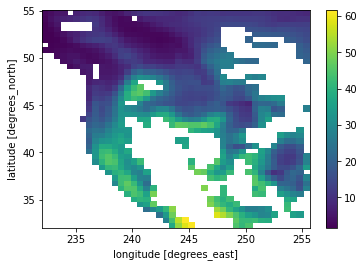

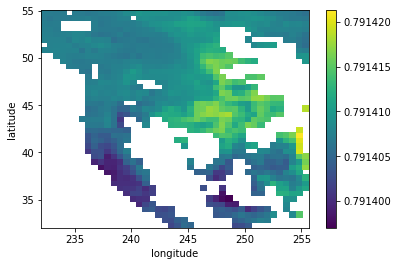

In [15]:
da.mean('time').plot()
plt.show()
plt.close(fig)

est_obs.mean('time').plot()
plt.show()
plt.close(fig)


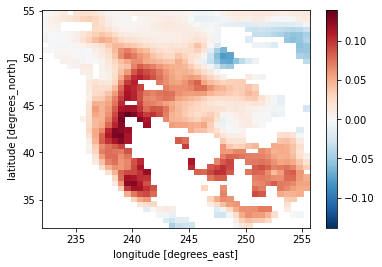

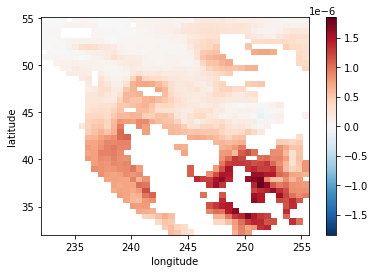

In [16]:
xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot()
plt.show()
plt.close(fig)

xr.apply_ufunc(get_linregress_slope, est_obs, input_core_dims=[["time"]], vectorize = True).plot()
plt.show()
plt.close(fig)


